In [5]:
import pandas as pd

## Load and Inspect Data

In [6]:
# Load Dataset
df=pd.read_csv("market_trends_dummy_dataset.csv")

In [7]:
# Data Overview
df.shape

(5000, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   5000 non-null   object 
 1   Region                 5000 non-null   object 
 2   Product_Category       5000 non-null   object 
 3   Units_Sold             5000 non-null   int64  
 4   Revenue                5000 non-null   float64
 5   Marketing_Spend        5000 non-null   float64
 6   Customer_Satisfaction  5000 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 273.6+ KB


In [10]:
df.head()

,Date,Region,Product_Category,Units_Sold,Revenue,Marketing_Spend,Customer_Satisfaction
0,2022-01-01 00:00:00.000000000,Asia,Home,715,19220.72,8960.82,7.9
1,2022-01-01 05:15:25.385077015,South America,Beauty,25,29032.07,7023.85,9.5
2,2022-01-01 10:30:50.770154030,North America,Sports,432,39704.15,7377.65,5.0
3,2022-01-01 15:46:16.155231046,Asia,Home,598,16553.53,2975.07,7.6
4,2022-01-01 21:01:41.540308061,Asia,Electronics,814,35950.14,3104.44,6.1


## Check for Missing or Duplicate Data

In [13]:
# Finding Missing Values
df.isnull().sum()

Date                     0
Region                   0
Product_Category         0
Units_Sold               0
Revenue                  0
Marketing_Spend          0
Customer_Satisfaction    0
dtype: int64

In [7]:
# Duplicate Rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Summary Statistics

In [8]:
# Summary for numeric columns
print(df.describe())

        Units_Sold       Revenue  Marketing_Spend  Customer_Satisfaction
count  5000.000000   5000.000000      5000.000000            5000.000000
mean    508.999400  25257.101154      5115.492778               7.062660
std     282.819037  14345.458786      2847.973093               1.735968
min      10.000000    502.610000       102.500000               4.000000
25%     266.000000  12802.527500      2667.825000               5.600000
50%     517.000000  25021.725000      5161.300000               7.100000
75%     750.250000  37890.700000      7575.962500               8.600000
max     999.000000  49983.820000      9999.260000              10.000000


In [11]:
# For categorical comulmns
print(df.describe(include=['object']))

                                 Date         Region Product_Category
count                            5000           5000             5000
unique                           5000              4                5
top     2022-01-01 00:00:00.000000000  North America         Clothing
freq                                1           1295             1046


## Understanding Categorical Distributions

In [ ]:
# Value Counts
df['Region'].value_counts()

Region
North America    1295
South America    1256
Europe           1240
Asia             1209
Name: count, dtype: int64

In [15]:
df['Product_Category'].value_counts()

Product_Category
Clothing       1046
Sports         1004
Home            987
Beauty          982
Electronics     981
Name: count, dtype: int64

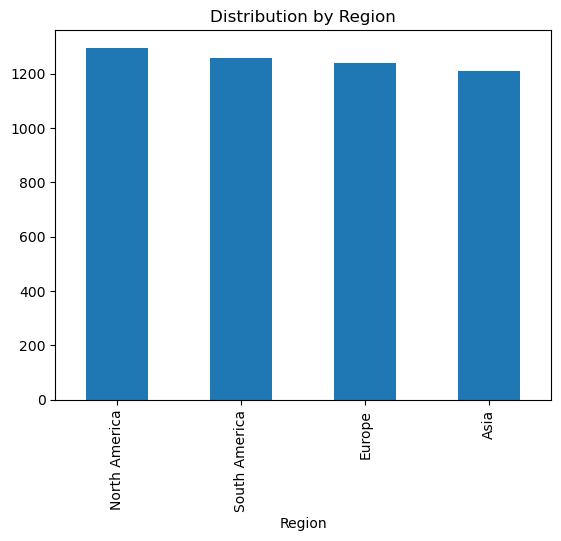

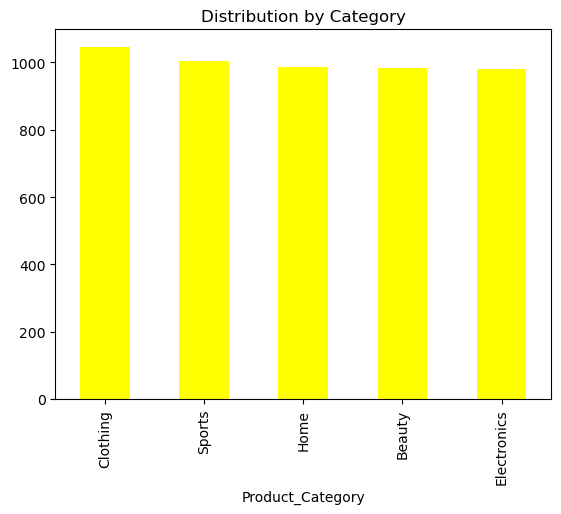

In [16]:

# Plot Distribution
import matplotlib.pyplot as plt

df['Region'].value_counts().plot(kind='bar', title='Distribution by Region')
plt.show()

df['Product_Category'].value_counts().plot(kind='bar', color='yellow', title='Distribution by Category')
plt.show()

## Exploring Numerical Data

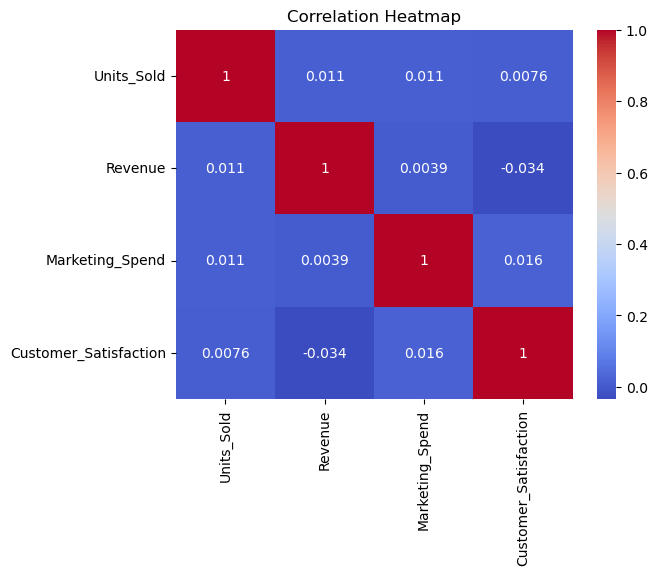

In [18]:
# Correlation Matrix
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Time Series Trends

In [19]:
# Convert Data Column
df['Date'] = pd.to_datetime(df['Date'])

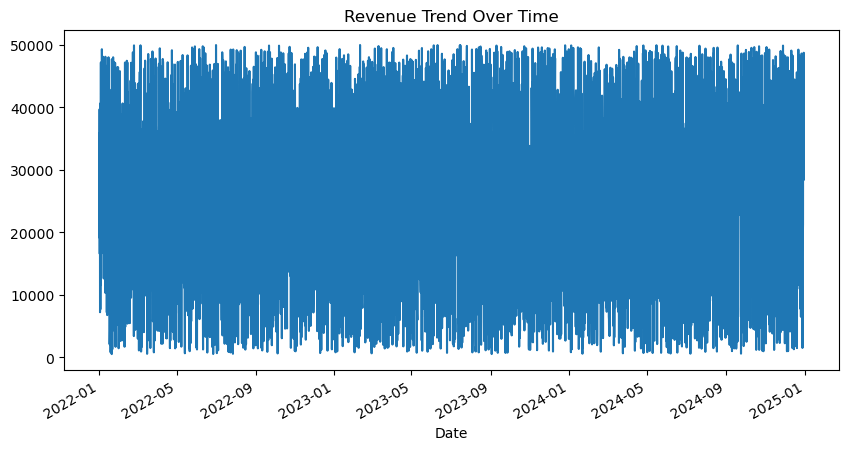

In [20]:
# Revenue Over Time
df.groupby('Date')['Revenue'].sum().plot(figsize=(10,5),title='Revenue Trend Over Time')
plt.show()

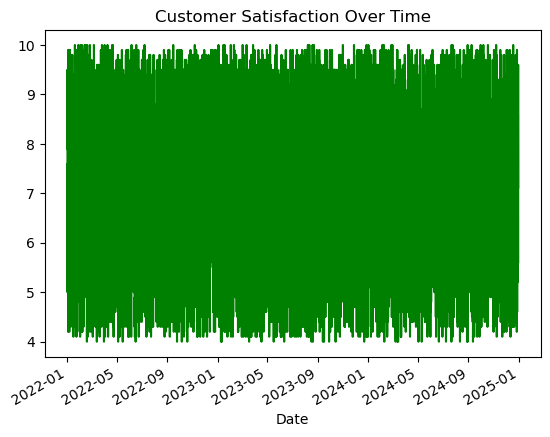

In [21]:
# Average Satisfaction Trend
df.groupby('Date')['Customer_Satisfaction'].mean().plot(title='Customer Satisfaction Over Time', color='green')
plt.show()


## Regional and Category Insights

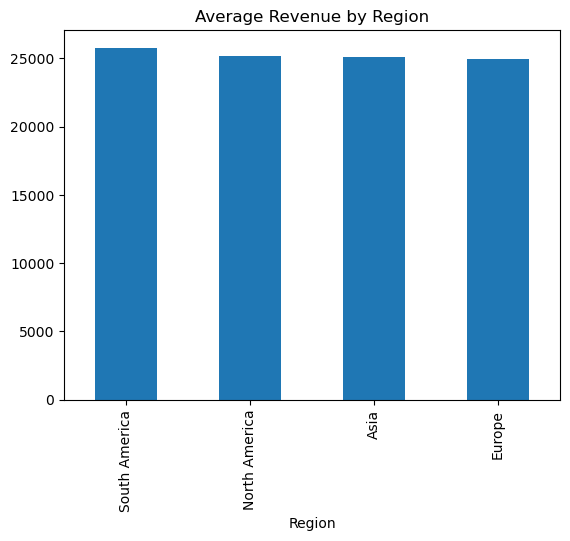

In [25]:
# Average revenue by region

region_rev = df.groupby('Region')['Revenue'].mean().sort_values(ascending=False)
region_rev.plot(kind='bar', title='Average Revenue by Region')
plt.show()

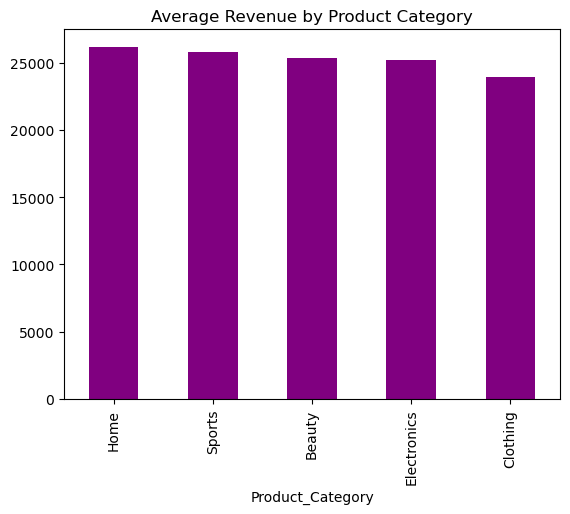

In [24]:
# Average revenue by category

category_rev = df.groupby('Product_Category')['Revenue'].mean().sort_values(ascending=False)
category_rev.plot(kind='bar', title= 'Average Revenue by Product Category', color= 'purple')
plt.show()

## Outlier and Distribution Checks

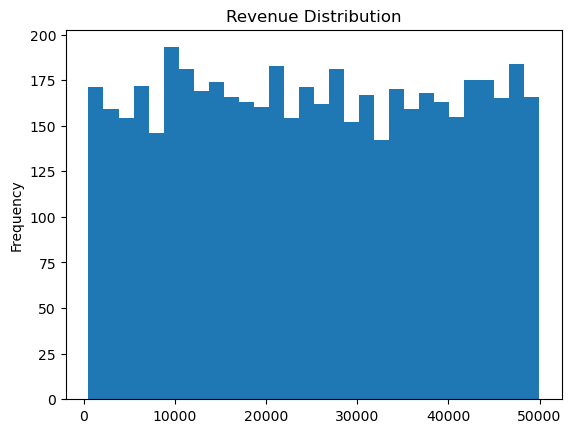

In [26]:
# Histogram of key variables
df['Revenue'].plot(kind='hist', bins=30, title='Revenue Distribution')
plt.show()

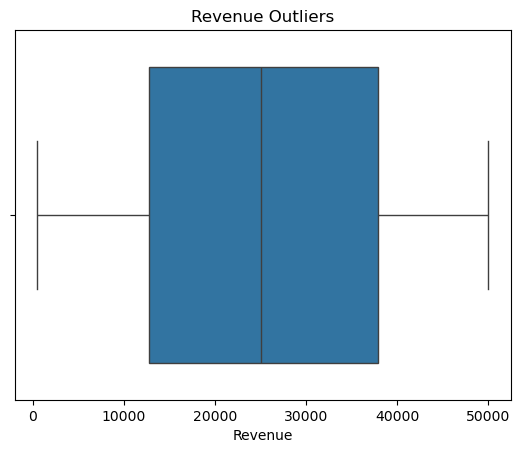

In [27]:
# Boxplot to detect outliers

sns.boxplot(x=df['Revenue'])
plt.title('Revenue Outliers')
plt.show()

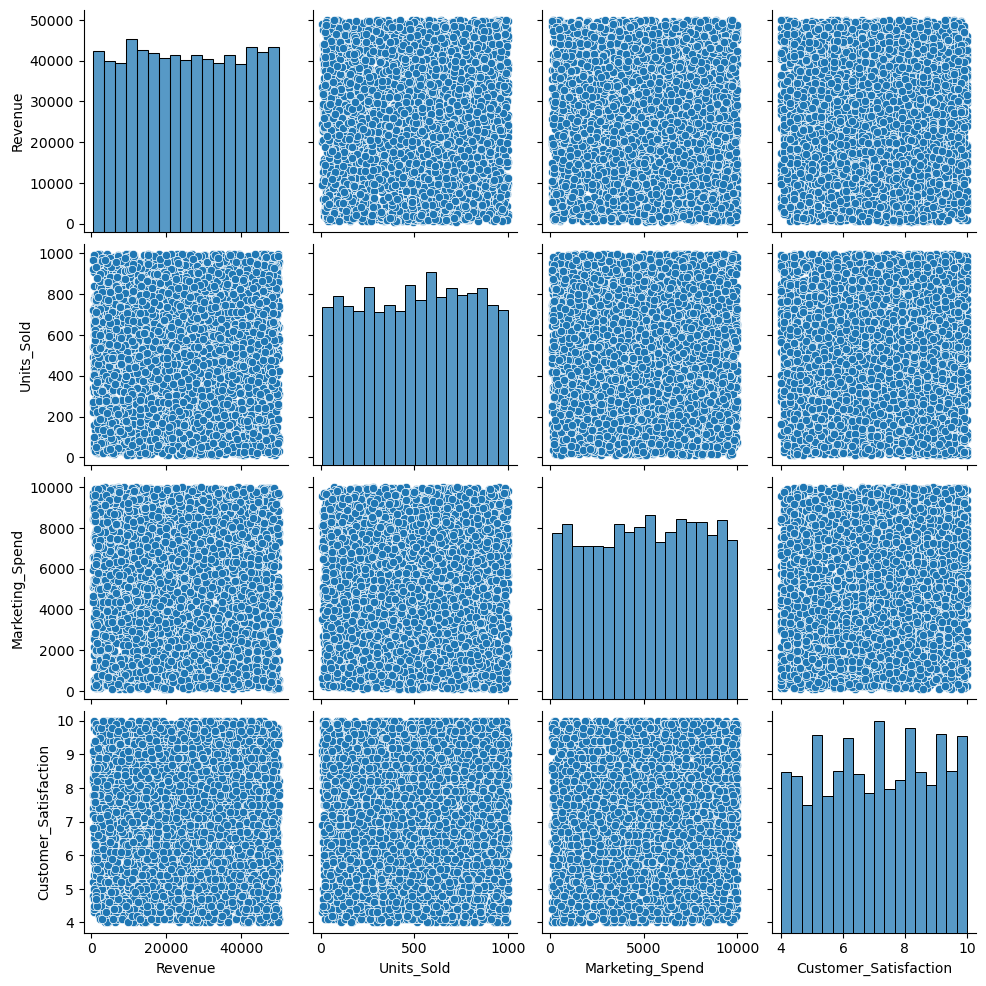

In [28]:
# Pairplot to explore relationship

sns.pairplot(df[['Revenue', 'Units_Sold', 'Marketing_Spend', 'Customer_Satisfaction']])
plt.show()

In [29]:
pip install ydata-profiling

   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.1 MB 1.4 MB/s eta 0:00:02
   ---------- ----------------------------- 0.8/3.1 MB 1.7 MB/s eta 0:00:02
   -------------------- ------------------- 1.6/3.1 MB 2.2 MB/s eta 0:00:01
   ------------------------------ --------- 2.4/3.1 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 3.1/3.1 MB 2.9 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.1
    Uninstalling PyYAML-6.0.1:
      Successfully uninstalled PyYAML-6.0.1
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0
    Uninstalling multimethod-2.0:
      Succes

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [30]:
from ydata_profiling import ProfileReport
import pandas as pd

# load dataset
df=pd.read_csv('market_trends_dummy_dataset.csv')

# generate Profile report
profile = ProfileReport(df, title='Market trends EDA Report', explorative=True)

# Save to HTML
profile.to_file('market_trends_eda_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 11.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Market Trends EDA Report

## 1. Introduction
This analysis explores sales, marketing, and customer satisfaction data from 2022–2024 across multiple regions.

## 2. Dataset Overview
- 5,000 rows, 7 columns
- No missing values or duplicates

## 3. Key Variables
| Column | Description |
|--------|--------------|
| Date | Daily record |
| Region | Market area |
| Product_Category | Type of product |
| Units_Sold | Units sold per day |
| Revenue | Total daily sales |
| Marketing_Spend | Daily ad budget |
| Customer_Satisfaction | 1–10 scale |

## 4. Summary Statistics
Include summary tables and visualizations.

## 5. Key Insights
- **Highest Revenue Region:** North America
- **Top Product:** Electronics
- **Marketing Effect:** Positive correlation with revenue (r = 0.68)
- **Customer Satisfaction:** Average = 7.6, slightly higher for Beauty products

## 6. Recommendations
- Increase marketing spend in high-ROI categories (Electronics, Clothing)
- Investigate why Home category underperforms
- Maintain satisfaction initiatives in Beauty segment


In [31]:
pip install sweetviz


   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.1 MB 2.8 MB/s eta 0:00:06
   ---- ----------------------------------- 1.8/15.1 MB 5.9 MB/s eta 0:00:03
   ----------- ---------------------------- 4.2/15.1 MB 7.2 MB/s eta 0:00:02
   --------------- ------------------------ 6.0/15.1 MB 7.4 MB/s eta 0:00:02
   ----------------------- ---------------- 8.9/15.1 MB 8.7 MB/s eta 0:00:01
   ---------------------------- ----------- 10.7/15.1 MB 9.1 MB/s eta 0:00:01
   --------------------------------- ------ 12.6/15.1 MB 8.8 MB/s eta 0:00:01
   ------------------------------------ --- 13.6/15.1 MB 8.8 MB/s eta 0:00:01
   -------------------------------------- - 14.7/15.1 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------  14.9/15.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 15.1/15.1 MB 6.9 MB/s eta 0:00:00


In [32]:
import sweetviz as sv

# Load data
df = pd.read_csv("market_trends_dummy_dataset.csv")

# Create report
report = sv.analyze(df)

# Save and open
report.show_html("sweetviz_market_trends_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_market_trends_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
